---
*  *Домашнее задание №4*
*  *Выполнил студент 2 курса магистратуры Аналитака данных*
*  *Владислав Шкаровский*
*  *группа S4201, ИСУ 472677*

Домашнее задание №4

Задача
В этом задании необходимо обучить генеративную модель VAE для генерации цветков. Датасет, который предлагается использовать, доступен по ссылке: https://www.kaggle.com/datasets/jeffheaton/iris-computer-vision/data
Он состоит из 441 изображений, разрешения 224x224x3
Ваша цель — обучить VAE для генерации растений
Рекомендации по выполнению:
Рекомендуется использовать ноутбук из практики, но его необходимо будет адаптировать под генерацию изображений в трех каналах
Можно использовать и другой любой код для выполнения данной задачи, но датасет при этом не менять
Изображения НЕ обязательно генерировать в разрешении 224x224x3. Можно их сжать до меньшего размера (например до 64x64x3). Это ускорит обучение и выполнение ДЗ 🙂


Формат сдачи
Сдавать необходимо оформленный ноутбук (.ipynb) с комментариями к коду и промежуточными выводами

# Материалы практики

In [1]:
!pip install pytorch-model-summary

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from pytorch_model_summary import summary

### Dataset

In this example, we go wild and use a dataset that is simpler than MNIST! We use a scipy dataset called Digits. It consists of ~1500 images of size 8x8, and each pixel can take values in $\{0, 1, \ldots, 16\}$.

The goal of using this dataset is that everyone can run it on a laptop, without any gpu etc.

In [ ]:
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode="train", transforms=None):
        digits = load_digits()
        if mode == "train":
            self.data = digits.data[:1000].astype(np.float32)
        elif mode == "val":
            self.data = digits.data[1000:1350].astype(np.float32)
        else:
            self.data = digits.data[1350:].astype(np.float32)

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

### VAE code

Please see the blogpost for details.

**Probability distributions**


log_categorical:

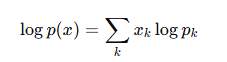

log_bernoulli:

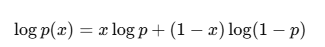

log_normal_diag:

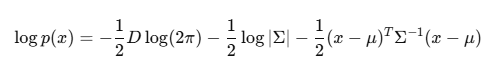

log_standard_normal:

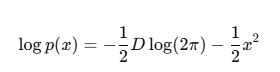

In [ ]:
PI = torch.from_numpy(np.asarray(np.pi))
EPS = 1.0e-5


def log_categorical(x, p, num_classes=256, reduction=None, dim=None):
    x_one_hot = F.one_hot(x.long(), num_classes=num_classes)
    log_p = x_one_hot * torch.log(torch.clamp(p, EPS, 1.0 - EPS))
    if reduction == "avg":
        return torch.mean(log_p, dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim)
    else:
        return log_p


def log_bernoulli(x, p, reduction=None, dim=None):
    pp = torch.clamp(p, EPS, 1.0 - EPS)
    log_p = x * torch.log(pp) + (1.0 - x) * torch.log(1.0 - pp)
    if reduction == "avg":
        return torch.mean(log_p, dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim)
    else:
        return log_p


def log_normal_diag(x, mu, log_var, reduction=None, dim=None):
    D = x.shape[1]
    log_p = (
        -0.5 * D * torch.log(2.0 * PI)
        - 0.5 * log_var
        - 0.5 * torch.exp(-log_var) * (x - mu) ** 2.0
    )
    if reduction == "avg":
        return torch.mean(log_p, dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim)
    else:
        return log_p


def log_standard_normal(x, reduction=None, dim=None):
    D = x.shape[1]
    log_p = -0.5 * D * torch.log(2.0 * PI) - 0.5 * x**2.0
    if reduction == "avg":
        return torch.mean(log_p, dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim)
    else:
        return log_p

**Encoder**

In [ ]:
class Encoder(nn.Module):
    def __init__(self, encoder_net):
        super(Encoder, self).__init__()

        self.encoder = encoder_net

    @staticmethod
    def reparameterization(mu, log_var):
        std = torch.exp(0.5 * log_var)

        eps = torch.randn_like(std)

        return mu + std * eps

    def encode(self, x):
        h_e = self.encoder(x)
        mu_e, log_var_e = torch.chunk(h_e, 2, dim=1)

        return mu_e, log_var_e

    def sample(self, x=None, mu_e=None, log_var_e=None):
        if (mu_e is None) and (log_var_e is None):
            mu_e, log_var_e = self.encode(x)
        else:
            if (mu_e is None) or (log_var_e is None):
                raise ValueError("mu and log-var can`t be None!")
        z = self.reparameterization(mu_e, log_var_e)
        return z

    def log_prob(self, x=None, mu_e=None, log_var_e=None, z=None):
        if x is not None:
            mu_e, log_var_e = self.encode(x)
            z = self.sample(mu_e=mu_e, log_var_e=log_var_e)
        else:
            if (mu_e is None) or (log_var_e is None) or (z is None):
                raise ValueError("mu, log-var and z can`t be None!")

        return log_normal_diag(z, mu_e, log_var_e)

    def forward(self, x, type="log_prob"):
        assert type in ["encode", "log_prob"], (
            "Type could be either encode or log_prob"
        )
        if type == "log_prob":
            return self.log_prob(x)
        else:
            return self.sample(x)

**Decoder**

In [ ]:
class Decoder(nn.Module):
    def __init__(self, decoder_net, distribution="categorical", num_vals=None):
        super(Decoder, self).__init__()

        self.decoder = decoder_net
        self.distribution = distribution
        self.num_vals = num_vals

    def decode(self, z):
        h_d = self.decoder(z)

        if self.distribution == "categorical":
            b = h_d.shape[0]
            d = h_d.shape[1] // self.num_vals
            h_d = h_d.view(b, d, self.num_vals)  # b , h*w, num_vals
            mu_d = torch.softmax(h_d, 2)
            return [mu_d]  # [b , h*w, num_vals]

        elif self.distribution == "bernoulli":
            mu_d = torch.sigmoid(h_d)  # b , h*w, 1
            return [mu_d]

        else:
            raise ValueError("Either `categorical` or `bernoulli`")

    def sample(self, z):
        outs = self.decode(z)

        if self.distribution == "categorical":
            mu_d = outs[0]  # b , h*w, num_vals
            b = mu_d.shape[0]
            m = mu_d.shape[1]
            mu_d = mu_d.view(mu_d.shape[0], -1, self.num_vals)
            p = mu_d.view(-1, self.num_vals)
            x_new = torch.multinomial(p, num_samples=1).view(b, m)

        elif self.distribution == "bernoulli":
            mu_d = outs[0]
            x_new = torch.bernoulli(mu_d)

        else:
            raise ValueError("Either `categorical` or `bernoulli`")

        return x_new

    def log_prob(self, x, z):
        outs = self.decode(z)  # 1, b , h*w, num_vals

        if self.distribution == "categorical":
            mu_d = outs[0]  # b , h*w, num_vals
            log_p = log_categorical(
                x, mu_d, num_classes=self.num_vals, reduction="sum", dim=-1
            ).sum(-1)

        elif self.distribution == "bernoulli":
            mu_d = outs[0]
            log_p = log_bernoulli(x, mu_d, reduction="sum", dim=-1)

        else:
            raise ValueError("Either `categorical` or `bernoulli`")

        return log_p

    def forward(self, z, x=None, type="log_prob"):
        assert type in ["decoder", "log_prob"], (
            "Type could be either decode or log_prob"
        )
        if type == "log_prob":
            return self.log_prob(x, z)
        else:
            return self.sample(z)

**Prior**

In [8]:
class Prior(nn.Module):
    def __init__(self, L):
        super(Prior, self).__init__()
        self.L = L

    def sample(self, batch_size):
        z = torch.randn((batch_size, self.L))
        return z

    def log_prob(self, z):
        return log_standard_normal(z)

**Full VAE**

In [ ]:
class VAE(nn.Module):
    def __init__(
        self,
        encoder_net,
        decoder_net,
        num_vals=256,
        L=16,
        likelihood_type="categorical",
    ):
        super(VAE, self).__init__()

        print("VAE by JT.")

        self.encoder = Encoder(encoder_net=encoder_net)
        self.decoder = Decoder(
            distribution=likelihood_type,
            decoder_net=decoder_net,
            num_vals=num_vals,
        )
        self.prior = Prior(L=L)

        self.num_vals = num_vals

        self.likelihood_type = likelihood_type

    def forward(self, x, reduction="avg"):
        # encoder
        mu_e, log_var_e = self.encoder.encode(x)
        z = self.encoder.sample(mu_e=mu_e, log_var_e=log_var_e)

        # ELBO
        RE = self.decoder.log_prob(x, z)  #
        KL = (
            self.prior.log_prob(z)
            - self.encoder.log_prob(mu_e=mu_e, log_var_e=log_var_e, z=z)
        ).sum(-1)

        if reduction == "sum":
            return -(RE + KL).sum()
        else:
            return -(RE + KL).mean()

    def sample(self, batch_size=64):
        z = self.prior.sample(batch_size=batch_size)  # b, m
        return self.decoder.sample(z)

### Auxiliary functions: training, evaluation, plotting

It's rather self-explanatory, isn't it?

In [ ]:
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        # load best performing model
        model_best = torch.load(name + ".model", weights_only=False)

    model_best.eval()
    loss = 0.0
    N = 0.0
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch, reduction="sum")
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f"FINAL LOSS: nll={loss}")
    else:
        print(f"Epoch: {epoch}, val nll={loss}")

    return loss


def samples_real(name, test_loader):
    # REAL-------
    num_x = 4
    num_y = 4
    x = next(iter(test_loader)).detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap="gray")
        ax.axis("off")

    plt.savefig(name + "_real_images.pdf", bbox_inches="tight")
    plt.close()


def samples_generated(name, data_loader, extra_name=""):
    x = next(iter(data_loader)).detach().numpy()

    # GENERATIONS-------
    model_best = torch.load(name + ".model", weights_only=False)
    model_best.eval()

    num_x = 4
    num_y = 4
    x = model_best.sample(num_x * num_y)
    x = x.detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap="gray")
        ax.axis("off")

    plt.savefig(
        name + "_generated_images" + extra_name + ".pdf", bbox_inches="tight"
    )
    plt.close()


def plot_curve(name, nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth="3")
    plt.xlabel("epochs")
    plt.ylabel("nll")
    plt.savefig(name + "_nll_val_curve.pdf", bbox_inches="tight")
    plt.close()

In [ ]:
def training(
    name,
    max_patience,
    num_epochs,
    model,
    optimizer,
    training_loader,
    val_loader,
):
    nll_val = []
    best_nll = 1000.0
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            if hasattr(model, "dequantization"):
                if model.dequantization:
                    batch = batch + torch.rand(batch.shape)
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)  # save for plotting

        if e == 0:
            print("saved!")
            torch.save(model, name + ".model")
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                print("saved!")
                torch.save(model, name + ".model")
                best_nll = loss_val
                patience = 0

                samples_generated(
                    name, val_loader, extra_name="_epoch_" + str(e)
                )
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)

    return nll_val

### Initialize dataloaders

In [ ]:
train_data = Digits(mode="train")
val_data = Digits(mode="val")
test_data = Digits(mode="test")

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

result_dir = "results/"
if not (os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = "vae"

### Hyperparams

In [ ]:
D = 64  # input dimension
L = 16  # number of latents
M = 256  # the number of neurons in scale (s) and translation (t) nets

lr = 1e-3  # learning rate
num_epochs = 1000  # max. number of epochs
max_patience = 20  # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

### Initialize VAE

In [ ]:
likelihood_type = "categorical"

if likelihood_type == "categorical":
    num_vals = 17
elif likelihood_type == "bernoulli":
    num_vals = 1

encoder = nn.Sequential(
    nn.Linear(D, M),
    nn.LeakyReLU(),
    nn.Linear(M, M),
    nn.LeakyReLU(),
    nn.Linear(M, 2 * L),
)

decoder = nn.Sequential(
    nn.Linear(L, M),
    nn.LeakyReLU(),
    nn.Linear(M, M),
    nn.LeakyReLU(),
    nn.Linear(M, num_vals * D),
)

prior = torch.distributions.MultivariateNormal(torch.zeros(L), torch.eye(L))
model = VAE(
    encoder_net=encoder,
    decoder_net=decoder,
    num_vals=num_vals,
    L=L,
    likelihood_type=likelihood_type,
)

# Print the summary (like in Keras)
print(
    "ENCODER:\n",
    summary(
        encoder, torch.zeros(1, D), show_input=False, show_hierarchical=False
    ),
)
print(
    "\nDECODER:\n",
    summary(
        decoder, torch.zeros(1, L), show_input=False, show_hierarchical=False
    ),
)

VAE by JT.
ENCODER:
 -----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1            [1, 256]          16,640          16,640
       LeakyReLU-2            [1, 256]               0               0
          Linear-3            [1, 256]          65,792          65,792
       LeakyReLU-4            [1, 256]               0               0
          Linear-5             [1, 32]           8,224           8,224
Total params: 90,656
Trainable params: 90,656
Non-trainable params: 0
-----------------------------------------------------------------------

DECODER:
 -----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
          Linear-1            [1, 256]           4,352           4,352
       LeakyReLU-2            [1, 256]               0               0
          Linear-3            [1, 256]     

### Let's play! Training

In [ ]:
# OPTIMIZER
optimizer = torch.optim.Adamax(
    [p for p in model.parameters() if p.requires_grad == True], lr=lr
)

In [ ]:
# Training procedure
nll_val = training(
    name=result_dir + name,
    max_patience=max_patience,
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    training_loader=training_loader,
    val_loader=val_loader,
)

Epoch: 0, val nll=126.03756766183035
saved!
Epoch: 1, val nll=113.46819056919642
saved!
Epoch: 2, val nll=112.10616629464286
saved!
Epoch: 3, val nll=111.96855678013392
saved!
Epoch: 4, val nll=111.6872314453125
saved!
Epoch: 5, val nll=111.59481236049108
saved!
Epoch: 6, val nll=111.65321986607142
Epoch: 7, val nll=111.58880440848215
saved!
Epoch: 8, val nll=111.42241071428572
saved!
Epoch: 9, val nll=111.07595703125
saved!
Epoch: 10, val nll=111.10899274553572
Epoch: 11, val nll=111.0405126953125
saved!
Epoch: 12, val nll=110.98114536830357
saved!
Epoch: 13, val nll=110.94280691964286
saved!
Epoch: 14, val nll=110.89008719308036
saved!
Epoch: 15, val nll=110.52805245535714
saved!
Epoch: 16, val nll=110.24878627232142
saved!
Epoch: 17, val nll=110.22745326450892
saved!
Epoch: 18, val nll=110.04710100446428
saved!
Epoch: 19, val nll=109.89068987165179
saved!
Epoch: 20, val nll=109.79201032366072
saved!
Epoch: 21, val nll=109.79364885602679
Epoch: 22, val nll=109.26141741071429
saved!
E

In [ ]:
test_loss = evaluation(name=result_dir + name, test_loader=test_loader)
f = open(result_dir + name + "_test_loss.txt", "w")
f.write(str(test_loss))
f.close()

samples_real(result_dir + name, test_loader)

plot_curve(result_dir + name, nll_val)

FINAL LOSS: nll=96.54495136849832


# Реализаци для ирисов

In [19]:
# Установка необходимых библиотек
!pip install pytorch-model-summary kaggle torchvision matplotlib pillow

In [ ]:
import os

import kagglehub
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from pytorch_model_summary import summary
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [ ]:
# проверка CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

# Константы из оригинального ноутбука
PI = torch.from_numpy(np.asarray(np.pi))
EPS = 1.0e-5

Используем устройство: cuda


In [ ]:
def logcategorical(x, p, num_classes=256, reduction=None, dim=None):
    """Log-likelihood для категориального распределения"""
    x_onehot = F.one_hot(x.long(), num_classes=num_classes)
    log_p = x_onehot * torch.log(torch.clamp(p, EPS, 1.0 - EPS))
    if reduction == "avg":
        return torch.mean(log_p, dim=dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim=dim)
    else:
        return log_p


def logbernoulli(x, p, reduction=None, dim=None):
    """Log-likelihood для бинарного распределения (для изображений)"""
    p = torch.clamp(p, EPS, 1.0 - EPS)
    log_p = x * torch.log(p) + (1.0 - x) * torch.log(1.0 - p)
    if reduction == "avg":
        return torch.mean(log_p, dim=dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim=dim)
    else:
        return log_p


def lognormal_diag(x, mu, logvar, reduction=None, dim=None):
    """Log-likelihood стандартного нормального распределения"""
    D = x.shape[1]
    log_p = (
        -0.5 * D * torch.log(2.0 * PI)
        - 0.5 * logvar
        - 0.5 * torch.exp(-logvar) * (x - mu) ** 2
    )
    if reduction == "avg":
        return torch.mean(log_p, dim=dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim=dim)
    else:
        return log_p


def logstandardnormal(x, reduction=None, dim=None):
    """Log-likelihood стандартного нормального N(0,I)"""
    D = x.shape[1]
    log_p = -0.5 * D * torch.log(2.0 * PI) - 0.5 * x**2
    if reduction == "avg":
        return torch.mean(log_p, dim=dim)
    elif reduction == "sum":
        return torch.sum(log_p, dim=dim)
    else:
        return log_p


In [ ]:
# Свёрточный энкодер для 64x64x3 изображений.
# Сжимает до латентного пространства
# размером 128. LeakyReLU(0.2) - стандарт для VAE.
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(Encoder, self).__init__()
        self.conv_net = nn.Sequential(
            # 3x64x64 -> 32x32x32
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32x32 -> 64x16x16
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 64x16x16 -> 128x8x8
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 128x8x8 -> 256x4x4
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 2 * latent_dim),  # mu + logvar
        )

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode(self, x):
        h = self.conv_net(x)
        mu_e, logvar_e = torch.chunk(h, 2, dim=1)
        return mu_e, logvar_e

    def sample(self, x=None, mu=None, logvar=None):
        if mu is None and logvar is None:
            mu, logvar = self.encode(x)
        elif mu is None or logvar is None:
            raise ValueError("mu and log-var can't be None!")
        z = self.reparameterize(mu, logvar)
        return z

    def logprob(self, x=None, mu=None, logvar=None, z=None):
        if x is not None:
            mu, logvar = self.encode(x)
            z = self.sample(mu=mu, logvar=logvar)
        elif mu is None or logvar is None or z is None:
            raise ValueError("mu, log-var and z can't be None!")
        return lognormal_diag(z, mu, logvar)

    def forward(self, x, type="logprob"):
        assert type in ["encode", "logprob"], (
            "Type could be either 'encode' or 'logprob'"
        )
        if type == "logprob":
            return self.logprob(x)
        else:
            return self.sample(x)


# Тест архитектуры
encoder = Encoder(latent_dim=128).to(device)
print("=== ENCODER ===")
summary(encoder, torch.zeros(1, 3, 64, 64).to(device), show_input=False)


=== ENCODER ===


'-----------------------------------------------------------------------\n      Layer (type)        Output Shape         Param #     Tr. Param #\n=======================================================================\n          Conv2d-1     [1, 32, 32, 32]           1,568           1,568\n       LeakyReLU-2     [1, 32, 32, 32]               0               0\n          Conv2d-3     [1, 64, 16, 16]          32,832          32,832\n       LeakyReLU-4     [1, 64, 16, 16]               0               0\n          Conv2d-5      [1, 128, 8, 8]         131,200         131,200\n       LeakyReLU-6      [1, 128, 8, 8]               0               0\n          Conv2d-7      [1, 256, 4, 4]         524,544         524,544\n       LeakyReLU-8      [1, 256, 4, 4]               0               0\n         Flatten-9           [1, 4096]               0               0\n         Linear-10            [1, 512]       2,097,664       2,097,664\n      LeakyReLU-11            [1, 512]               0       

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=128, num_channels=3):
        super(Decoder, self).__init__()
        self.latent_dim = latent_dim
        self.num_channels = num_channels

        self.decoder = nn.Sequential(
            # z -> 256x4x4
            nn.Linear(latent_dim, 256 * 4 * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Unflatten(1, (256, 4, 4)),
            # 256x4x4 -> 128x8x8
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 128x8x8 -> 64x16x16
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 64x16x16 -> 32x32x32
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32x32 -> 3x64x64
            nn.ConvTranspose2d(32, num_channels, 4, stride=2, padding=1),
            nn.Sigmoid(),  # Выход в [0,1] для изображений
        )

    def decode(self, z):
        """Реконструкция изображения из латентного вектора"""
        batch_size = z.size(0)
        return self.decoder(z).view(batch_size, self.num_channels, 64, 64)

    def sample(self, z):
        """Генерация нового изображения"""
        return self.decode(z)

    def logprob(self, x, z):
        """Log-likelihood реконструкции"""
        mu = self.decode(z)
        # x и mu: [B, C, H, W] -> [B, C*H*W]
        x_flat = x.view(x.size(0), -1)
        mu_flat = mu.view(mu.size(0), -1)
        log_p = logbernoulli(x_flat, mu_flat, reduction="sum")
        return log_p

    def forward(self, z, x=None, type="decode"):
        assert type in ["decode", "logprob"], (
            "Type could be either 'decode' or 'logprob'"
        )
        if type == "logprob":
            return self.logprob(x, z)
        else:
            return self.sample(z)


# Тест архитектуры (только decode)
decoder = Decoder(latent_dim=128).to(device)
print("=== DECODER ===")
summary(decoder, torch.zeros(1, 128).to(device), show_input=False)

=== DECODER ===


'--------------------------------------------------------------------------\n         Layer (type)        Output Shape         Param #     Tr. Param #\n==========================================================================\n             Linear-1           [1, 4096]         528,384         528,384\n          LeakyReLU-2           [1, 4096]               0               0\n          Unflatten-3      [1, 256, 4, 4]               0               0\n    ConvTranspose2d-4      [1, 128, 8, 8]         524,416         524,416\n          LeakyReLU-5      [1, 128, 8, 8]               0               0\n    ConvTranspose2d-6     [1, 64, 16, 16]         131,136         131,136\n          LeakyReLU-7     [1, 64, 16, 16]               0               0\n    ConvTranspose2d-8     [1, 32, 32, 32]          32,800          32,800\n          LeakyReLU-9     [1, 32, 32, 32]               0               0\n   ConvTranspose2d-10      [1, 3, 64, 64]           1,539           1,539\n           Sigmoid-11 

In [ ]:
class Prior(nn.Module):
    def __init__(self, L=128):
        super(Prior, self).__init__()
        self.L = L

    def sample(self, batch_size):
        z = torch.randn(batch_size, self.L).to(device)
        return z

    def logprob(self, z):
        return logstandardnormal(z)


class VAE(nn.Module):
    def __init__(
        self, encoder_net, decoder_net, L=128, likelihood_type="bernoulli"
    ):
        super(VAE, self).__init__()
        print("VAE для цветков ирисов (64x64x3)")

        self.encoder = (
            Encoder(encoder_net)
            if isinstance(encoder_net, dict)
            else encoder_net
        )
        self.decoder = Decoder(
            decoder_net.latent_dim if hasattr(decoder_net, "latent_dim") else L
        )
        self.prior = Prior(L)
        self.L = L
        self.likelihood_type = likelihood_type

    def forward(self, x, reduction="avg"):
        # Энкодер: x -> mu, logvar -> z
        mu_e, logvar_e = self.encoder.encode(x)
        z = self.encoder.sample(mu=mu_e, logvar=logvar_e)

        # ELBO = Reconstruction + KL
        RE = self.decoder.logprob(x, z)  # Reconstruction error
        KL = self.prior.logprob(z) - self.encoder.logprob(
            mu=mu_e, logvar=logvar_e, z=z
        )
        KL = KL.sum(-1)  # Суммируем по латентным размерностям

        elbo = -RE - KL
        if reduction == "sum":
            return elbo.sum()
        else:
            return elbo.mean()

    def sample(self, batch_size=64):
        z = self.prior.sample(batch_size)
        return self.decoder.sample(z)


# Инициализация полной модели
encoder_net = Encoder(latent_dim=128).to(device)
decoder_net = Decoder(latent_dim=128).to(device)
vae = VAE(encoder_net, decoder_net, L=128, likelihood_type="bernoulli").to(
    device
)

print("\n=== ПОЛНАЯ VAE ===")
total_params = sum(p.numel() for p in vae.parameters())
print(f"Всего параметров: {total_params:,}")

VAE для цветков ирисов (64x64x3)

=== ПОЛНАЯ VAE ===
Всего параметров: 4,137,411


In [ ]:
# Загрузка изображения
path = kagglehub.dataset_download("jeffheaton/iris-computer-vision")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iris-computer-vision' dataset.
Path to dataset files: /kaggle/input/iris-computer-vision


In [ ]:
# Ищем JPG файлы в датасете
print("=== Поиск изображений в датасете ===")
print(f"Путь к датасету: {path}")

# Рекурсивный поиск всех JPG
all_jpgs = []
for root, dirs, files in os.walk(path):
    jpgs = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if jpgs:
        print(f"Найдено в {root}: {len(jpgs)} файлов")
        all_jpgs.extend([os.path.join(root, f) for f in jpgs])

print(f"\nВсего изображений: {len(all_jpgs)}")
print("Первые 5 файлов:")
for f in all_jpgs[:5]:
    print(f"  {f}")

# Используем все найденные файлы
data_dir = path
all_files = [os.path.basename(f) for f in all_jpgs]


class IrisDataset(Dataset):
    def __init__(self, file_list, mode="train", transform=None):
        self.transform = transform
        self.files = file_list

        # Разделение 80/10/10
        n_train = int(0.8 * len(self.files))
        n_val = int(0.1 * len(self.files))

        if mode == "train":
            self.files = self.files[:n_train]
        elif mode == "val":
            self.files = self.files[n_train : n_train + n_val]
        else:
            self.files = self.files[n_train + n_val :]

        print(f"{mode}: {len(self.files)} файлов")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        full_path = os.path.join(data_dir, self.files[idx])
        image = Image.open(full_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image.float() / 255.0


transform = transforms.Compose(
    [transforms.Resize((64, 64)), transforms.ToTensor()]
)

# Создаем датасеты
train_dataset = IrisDataset(all_files, mode="train", transform=transform)
val_dataset = IrisDataset(all_files, mode="val", transform=transform)
test_dataset = IrisDataset(all_files, mode="test", transform=transform)


=== Поиск изображений в датасете ===
Путь к датасету: /kaggle/input/iris-computer-vision
Найдено в /kaggle/input/iris-computer-vision/iris-setosa: 67 файлов
Найдено в /kaggle/input/iris-computer-vision/iris-versicolour: 269 файлов
Найдено в /kaggle/input/iris-computer-vision/iris-virginica: 85 файлов

Всего изображений: 421
Первые 5 файлов:
  /kaggle/input/iris-computer-vision/iris-setosa/iris-7e9947110916b594c050f014171bf50d20d9885bc19b62b73b048e9427b97fa5.jpg
  /kaggle/input/iris-computer-vision/iris-setosa/iris-9675d304f0ef47c3a07c34becdb800047c2482a58f4a82497168f14839f022e1.jpg
  /kaggle/input/iris-computer-vision/iris-setosa/iris-ea0c9679108abba869e7a84d20bf01284491124a77f85e076400ea3fff83d673.jpg
  /kaggle/input/iris-computer-vision/iris-setosa/iris-2abfd90b157f1bc4170c24cc8c258d776a58926f0efca787961210f60bce76be.jpg
  /kaggle/input/iris-computer-vision/iris-setosa/iris-70069edd7ab0b829b84bb6d4465b2ca4038e129bb19d0d3f2ba671adc03398cc.jpg
train: 336 файлов
val: 42 файлов
test: 43 

train: 336 файлов
val: 42 файлов
test: 43 файлов

=== DataLoader'ы готовы ===
Train: 11 batches, Val: 2, Test: 2

=== ЦВЕТНЫЕ цветки ирисов ===


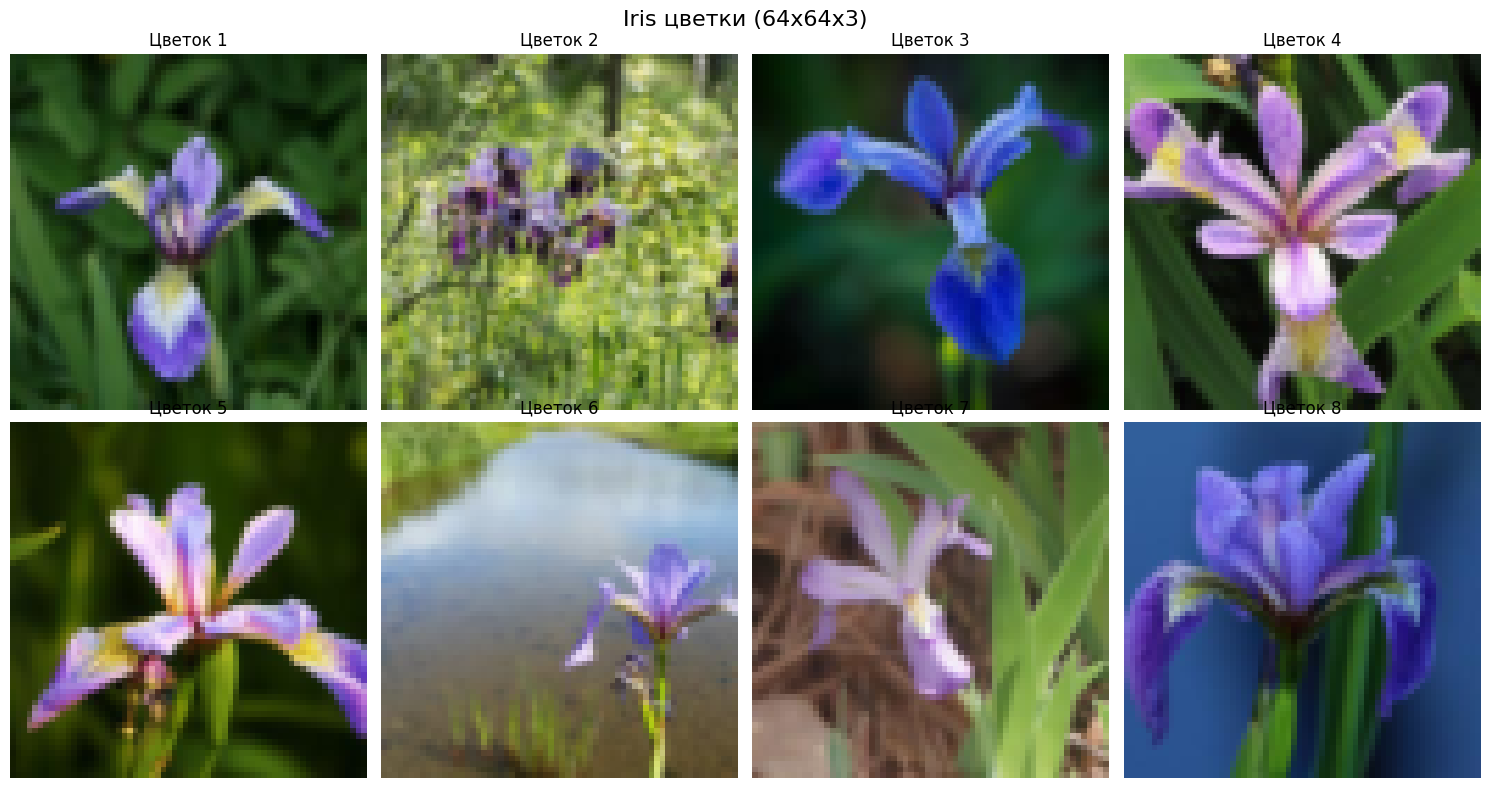

In [ ]:
# Dataset с нормализацией
class IrisDatasetFixed(Dataset):
    def __init__(self, file_list, mode="train", transform=None):
        self.transform = transform
        self.files = file_list.copy()

        n_train = int(0.8 * len(self.files))
        n_val = int(0.1 * len(self.files))

        if mode == "train":
            self.files = self.files[:n_train]
        elif mode == "val":
            self.files = self.files[n_train : n_train + n_val]
        else:
            self.files = self.files[n_train + n_val :]

        print(f"{mode}: {len(self.files)} файлов")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        full_path = self.files[idx]
        image = Image.open(full_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        # Нормализация [0,255] -> [0,1]
        return image  # ToTensor() уже делит на 255!


# Трансформации
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),  # Автоматически [0,255] -> [0,1]
    ]
)

train_dataset = IrisDatasetFixed(all_jpgs, mode="train", transform=transform)
val_dataset = IrisDatasetFixed(all_jpgs, mode="val", transform=transform)
test_dataset = IrisDatasetFixed(all_jpgs, mode="test", transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\n=== DataLoader'ы готовы ===")
print(
    (
        f"Train: {len(train_loader)} batches, "
        f"Val: {len(val_loader)}, Test: {len(test_loader)}"
    )
)


# Визуализация
def show_sample_batch(loader, title="Iris цветки (64x64x3)"):
    dataiter = iter(loader)
    images = next(dataiter)
    images = images[:8].clamp(0, 1)  # Гарантируем [0,1]

    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    for i, ax in enumerate(axes.flat):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.set_title(f"Цветок {i + 1}")
        ax.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


print("\n=== ЦВЕТНЫЕ цветки ирисов ===")
show_sample_batch(train_loader)


In [ ]:
def evaluate(test_loader, model, epoch=None):
    """Оценка модели на валидации"""
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            loss = model(batch, reduction="sum")
            total_loss += loss.item()
            total_samples += batch.size(0)

    avg_loss = total_loss / total_samples
    if epoch is None:
        print(f"FINAL LOSS (NLL): {avg_loss:.4f}")
    else:
        print(f"Epoch {epoch}: val NLL {avg_loss:.4f}")
    return avg_loss


def generate_samples(model, n_samples=16, name="samples"):
    """Генерация новых изображений"""
    model.eval()
    with torch.no_grad():
        samples = model.sample(n_samples).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        img = samples[i].permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.axis("off")
    plt.suptitle(f"Сгенерированные ирисы ({name})")
    plt.tight_layout()
    plt.savefig(f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


def train_vae(
    model, train_loader, val_loader, epochs=100, lr=1e-3, patience=15
):
    """Основной цикл обучения"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = float("inf")
    patience_counter = 0
    losses = []

    print("Начинаем обучение VAE...")
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = model(batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        # Validate
        val_loss = evaluate(val_loader, model, epoch)
        losses.append(val_loss)

        # Early stopping + сохранение лучшей модели
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_iris_vae.pth")
            patience_counter = 0
            print("Сохранена лучшая модель!")
            if epoch % 10 == 0:
                generate_samples(model, name=f"epoch_{epoch}")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping на эпохе {epoch}")
            break

    print(f"Обучение завершено. Лучший NLL: {best_loss:.4f}")
    return losses


print("Функции обучения готовы!")


Функции обучения готовы!


=== НАЧИНАЕМ ОБУЧЕНИЕ VAE ИРИСОВ ===
Эпох: 150, LR: 0.001, Batch: 32
Latent dim: 128, Датасет: 421 изображений
--------------------------------------------------
VAE для цветков ирисов (64x64x3)
Начинаем обучение VAE...
Epoch 0: val NLL 217306.9658
Сохранена лучшая модель!


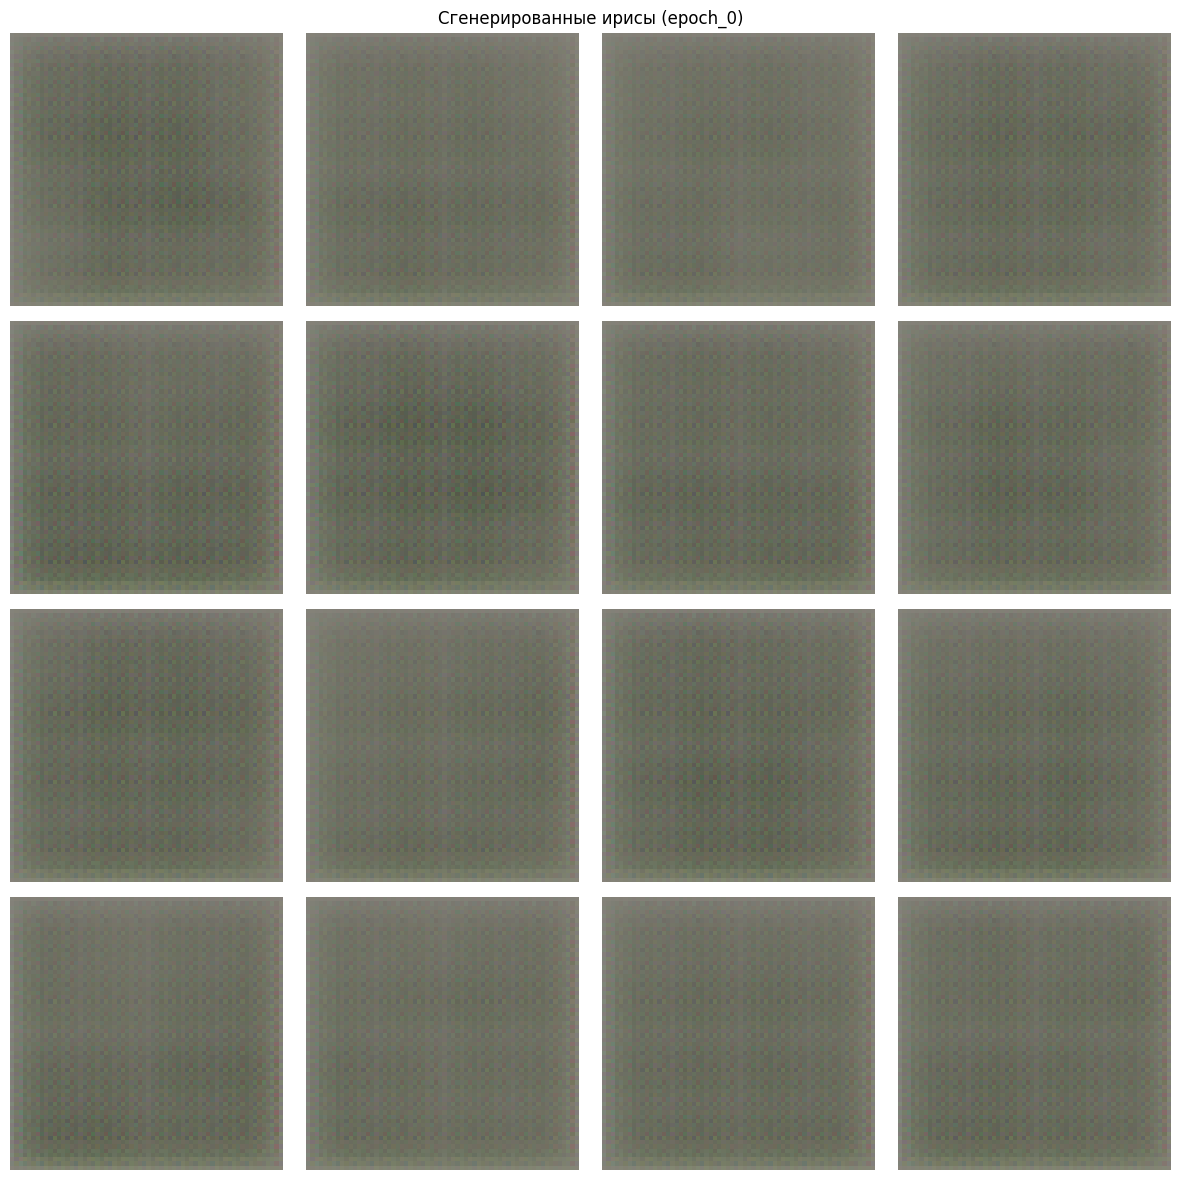

Epoch 1: val NLL 209787.7113
Сохранена лучшая модель!
Epoch 2: val NLL 207400.5283
Сохранена лучшая модель!
Epoch 3: val NLL 204223.8036
Сохранена лучшая модель!
Epoch 4: val NLL 202525.7917
Сохранена лучшая модель!
Epoch 5: val NLL 203881.2589
Epoch 6: val NLL 203392.2470
Epoch 7: val NLL 199816.6265
Сохранена лучшая модель!
Epoch 8: val NLL 200657.2262
Epoch 9: val NLL 199365.4107
Сохранена лучшая модель!
Epoch 10: val NLL 198295.6399
Сохранена лучшая модель!


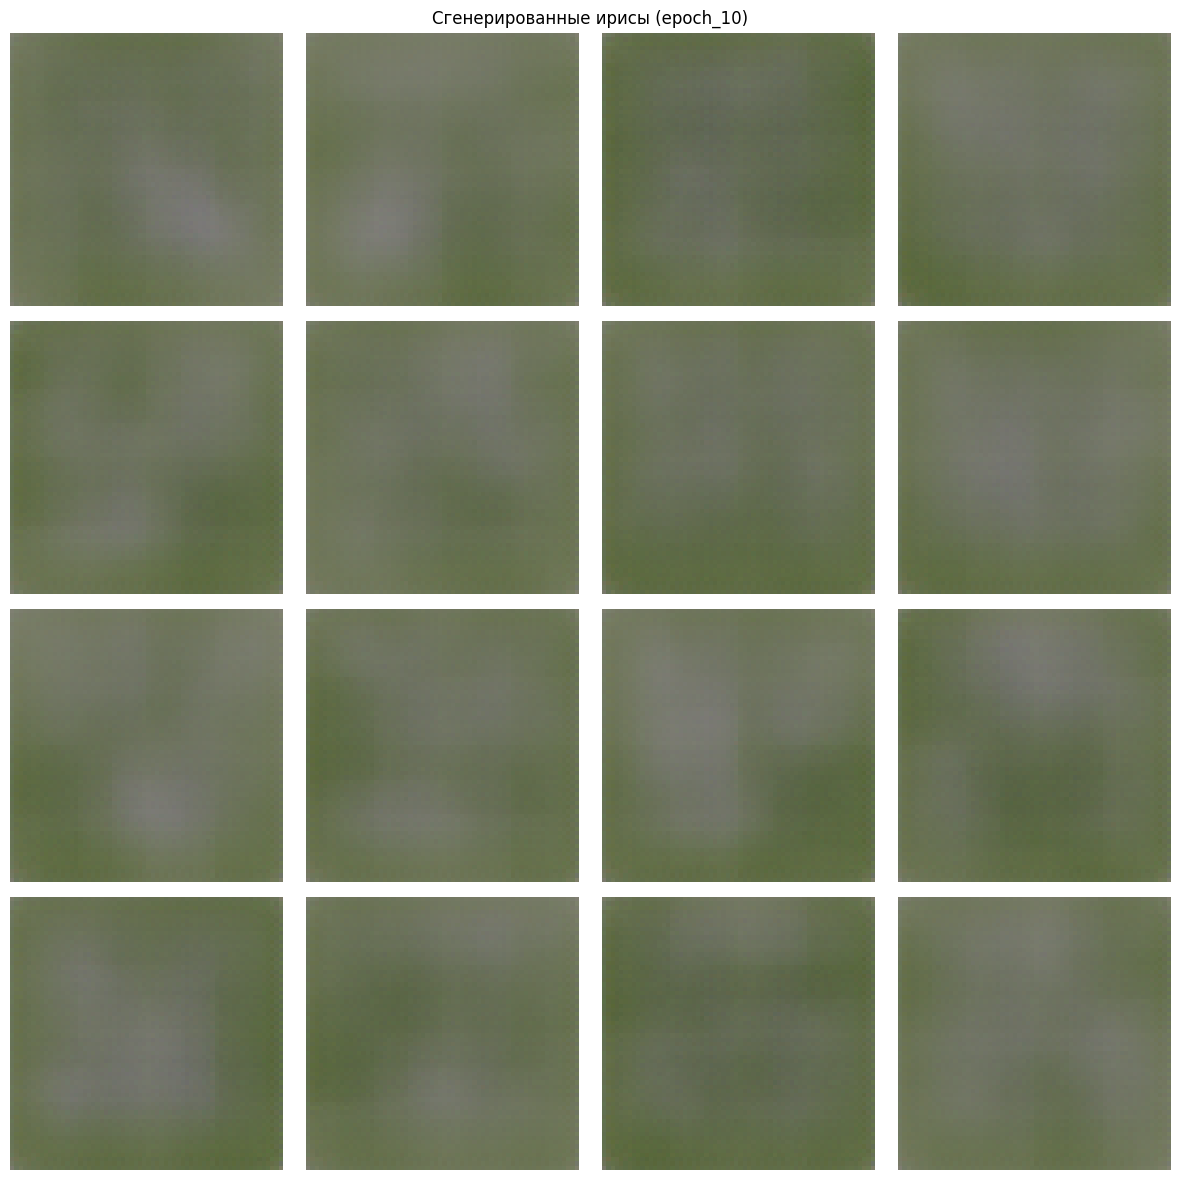

Epoch 11: val NLL 197725.8185
Сохранена лучшая модель!
Epoch 12: val NLL 198736.7798
Epoch 13: val NLL 196880.2872
Сохранена лучшая модель!
Epoch 14: val NLL 196433.9375
Сохранена лучшая модель!
Epoch 15: val NLL 196160.5818
Сохранена лучшая модель!
Epoch 16: val NLL 195583.5833
Сохранена лучшая модель!
Epoch 17: val NLL 196531.9509
Epoch 18: val NLL 195969.6845
Epoch 19: val NLL 195271.6101
Сохранена лучшая модель!
Epoch 20: val NLL 195840.0774
Epoch 21: val NLL 194678.4315
Сохранена лучшая модель!
Epoch 22: val NLL 193900.9345
Сохранена лучшая модель!
Epoch 23: val NLL 193624.4792
Сохранена лучшая модель!
Epoch 24: val NLL 193593.0268
Сохранена лучшая модель!
Epoch 25: val NLL 193668.5432
Epoch 26: val NLL 193551.2560
Сохранена лучшая модель!
Epoch 27: val NLL 192658.3661
Сохранена лучшая модель!
Epoch 28: val NLL 199945.5476
Epoch 29: val NLL 194947.3899
Epoch 30: val NLL 193524.8631
Epoch 31: val NLL 193358.5923
Epoch 32: val NLL 193159.0417
Epoch 33: val NLL 192393.9702
Сохранена 

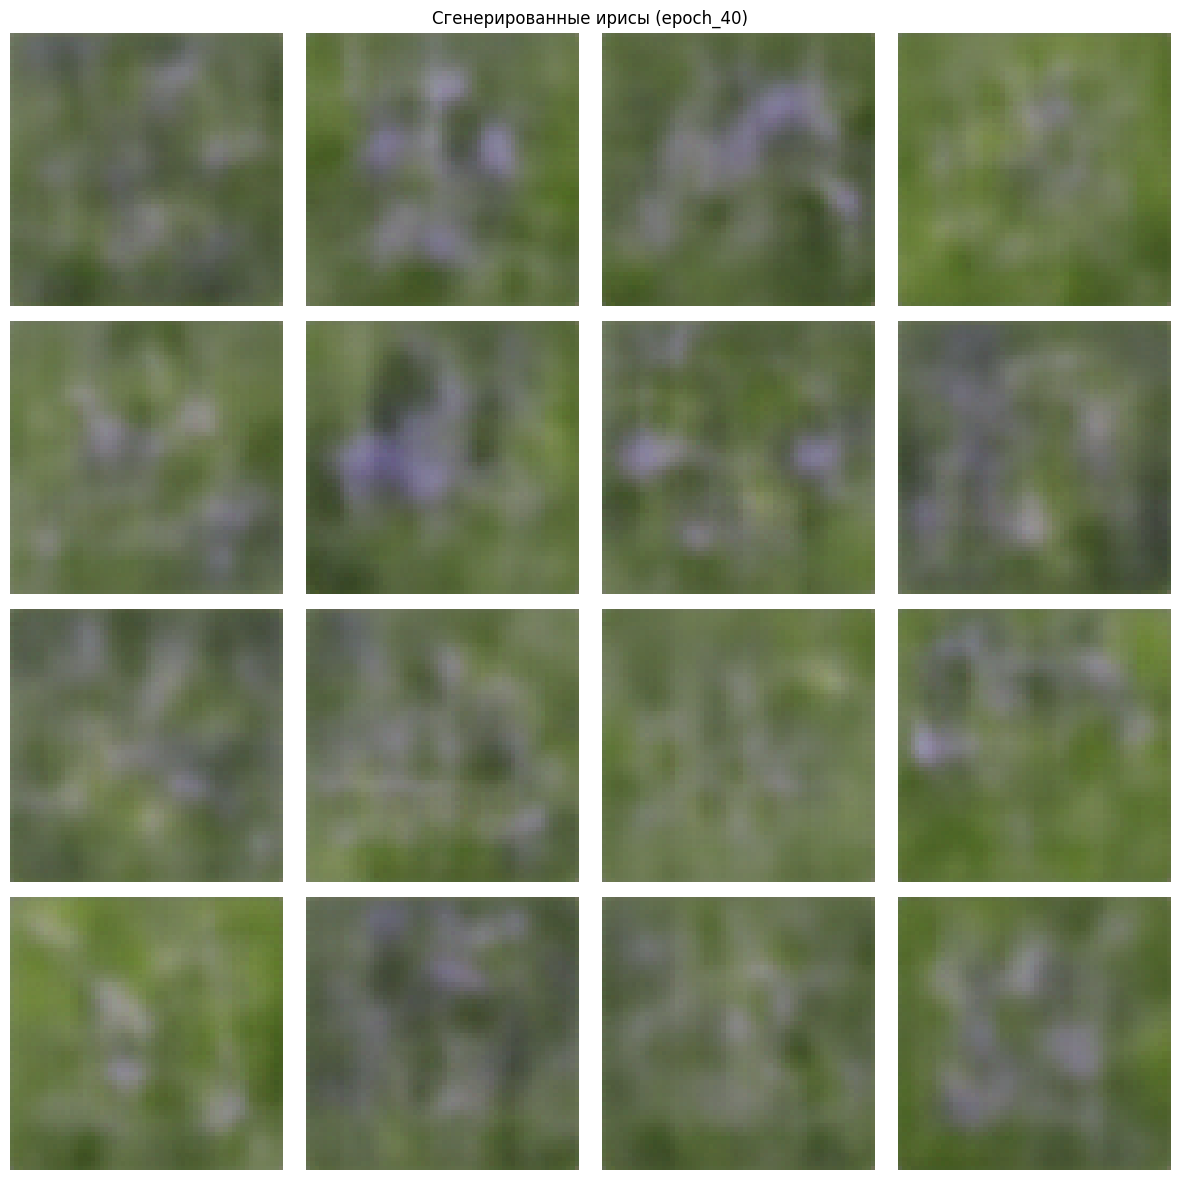

Epoch 41: val NLL 191810.8036
Сохранена лучшая модель!
Epoch 42: val NLL 191465.6042
Сохранена лучшая модель!
Epoch 43: val NLL 192202.3929
Epoch 44: val NLL 193691.7991
Epoch 45: val NLL 191996.2366
Epoch 46: val NLL 192143.6176
Epoch 47: val NLL 191799.3363
Epoch 48: val NLL 191820.2649
Epoch 49: val NLL 192768.7232
Epoch 50: val NLL 193076.7946
Epoch 51: val NLL 193156.2946
Epoch 52: val NLL 192982.2217
Epoch 53: val NLL 192285.0804
Epoch 54: val NLL 191991.1161
Epoch 55: val NLL 192112.0506
Epoch 56: val NLL 193022.4732
Epoch 57: val NLL 192263.7768
Epoch 58: val NLL 192155.5342
Epoch 59: val NLL 192183.6429
Epoch 60: val NLL 192354.3929
Epoch 61: val NLL 192691.9196
Epoch 62: val NLL 192225.9048
Early stopping на эпохе 62
Обучение завершено. Лучший NLL: 191465.6042

 ОБУЧЕНИЕ ЗАВЕРШЕНО!
=== ФИНАЛЬНАЯ ОЦЕНКА ===
FINAL LOSS (NLL): 183530.7297


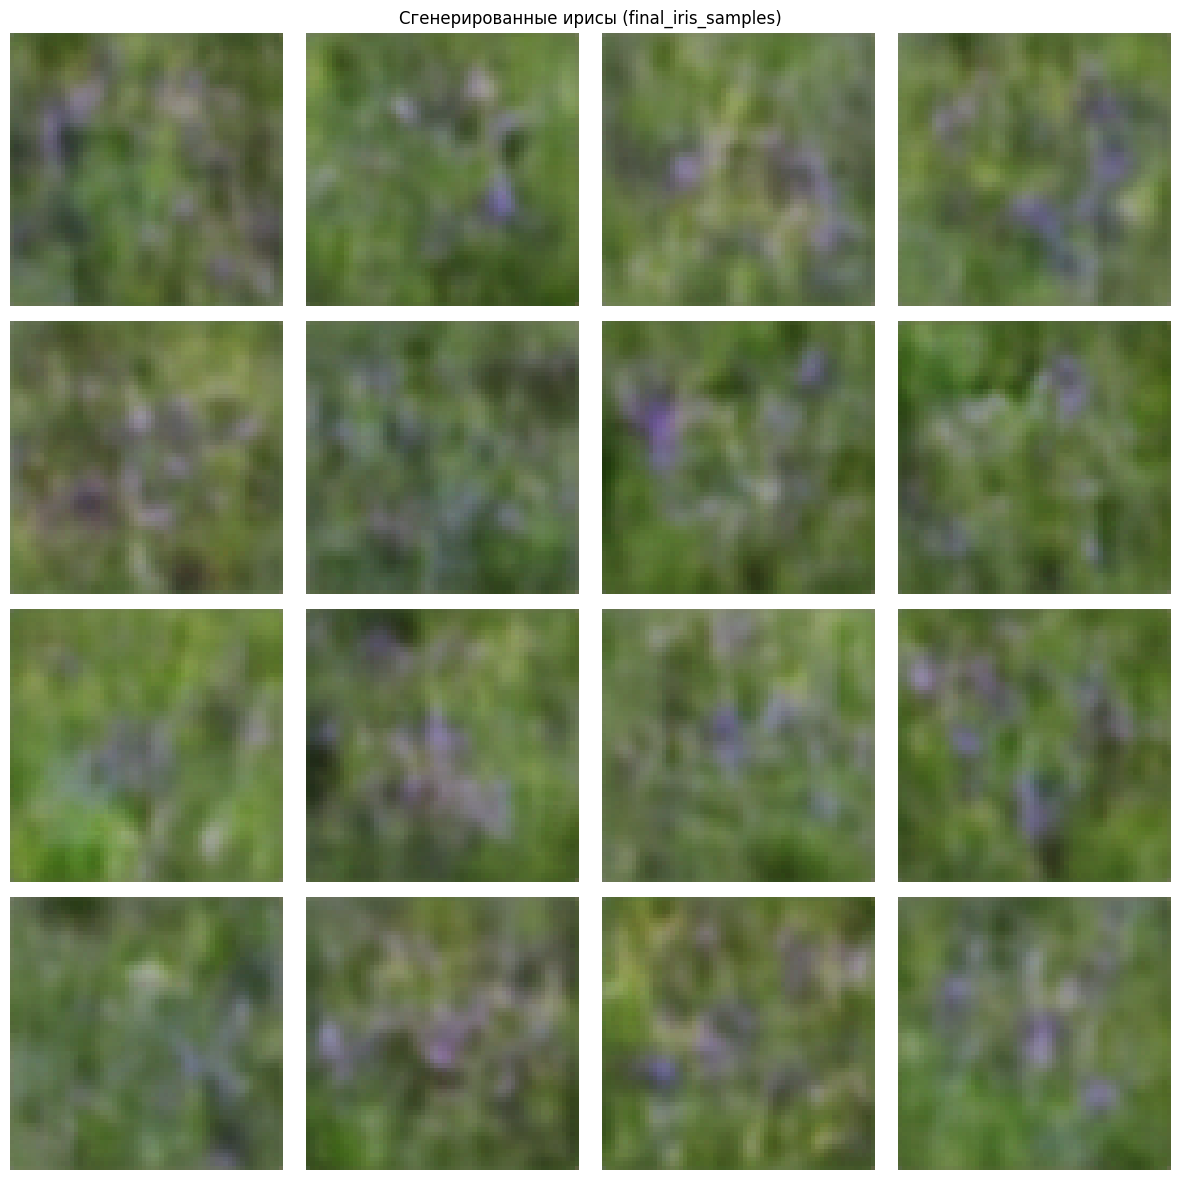

In [ ]:
# ГИПЕРПАРАМЕТРЫ (можно настроить)
epochs = 150
lr = 1e-3
batch_size = 32
latent_dim = 128

print("=== НАЧИНАЕМ ОБУЧЕНИЕ VAE ИРИСОВ ===")
print(f"Эпох: {epochs}, LR: {lr}, Batch: {batch_size}")
print(f"Latent dim: {latent_dim}, Датасет: 421 изображений")
print("-" * 50)

# Пересоздаем модель (если нужно сбросить)
vae = VAE(
    Encoder(latent_dim=latent_dim),
    Decoder(latent_dim=latent_dim),
    L=latent_dim,
    likelihood_type="bernoulli",
).to(device)

# Загружаем лучшую модель если есть
if os.path.exists("best_iris_vae.pth"):
    vae.load_state_dict(torch.load("best_iris_vae.pth", weights_only=True))
    print("🔄 Загружена сохраненная модель")

# ОБУЧЕНИЕ
losses = train_vae(
    model=vae,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    lr=lr,
    patience=20,
)

print("\n ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("=== ФИНАЛЬНАЯ ОЦЕНКА ===")
final_loss = evaluate(test_loader, vae)
generate_samples(vae, n_samples=16, name="final_iris_samples")


=== РЕАЛЬНЫЕ vs СГЕНЕРИРОВАННЫЕ ИРИСЫ ===
1. РЕАЛЬНЫЕ ирисы:


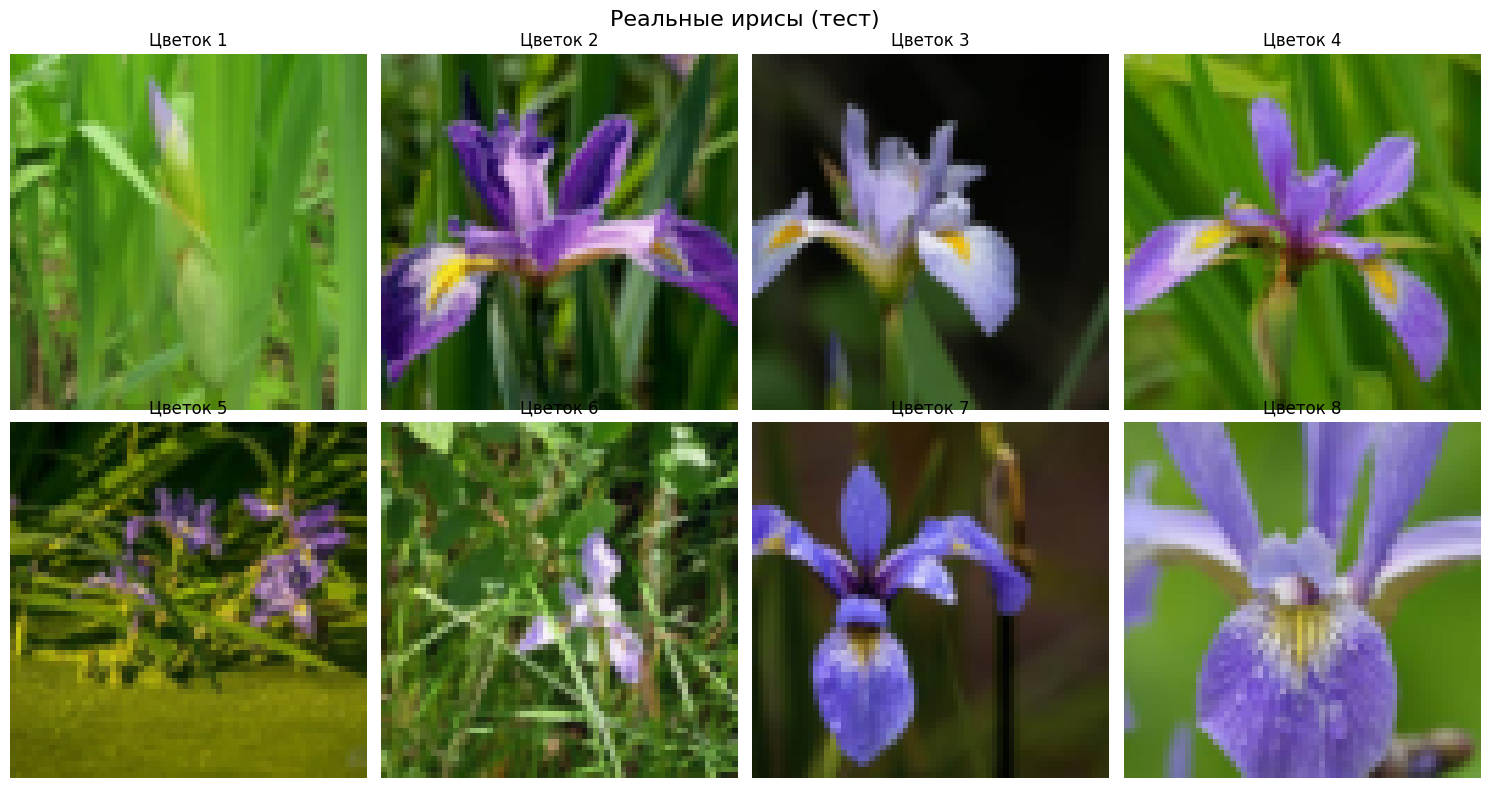

2. СГЕНЕРИРОВАННЫЕ ирисы:


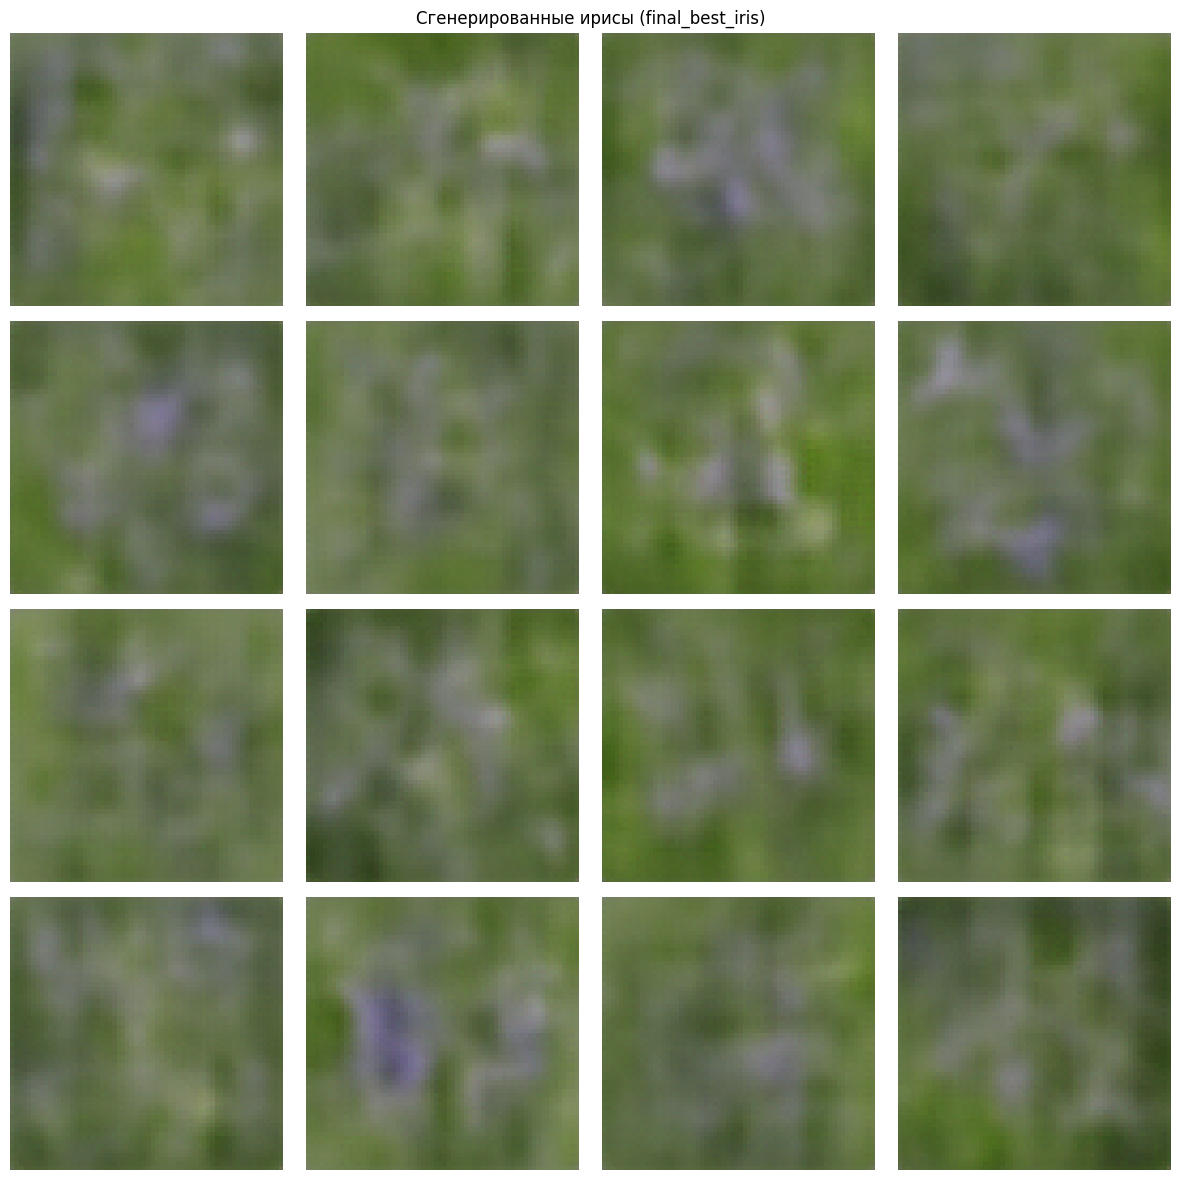

3. РЕКОНСТРУКЦИЯ (x -> z -> x):


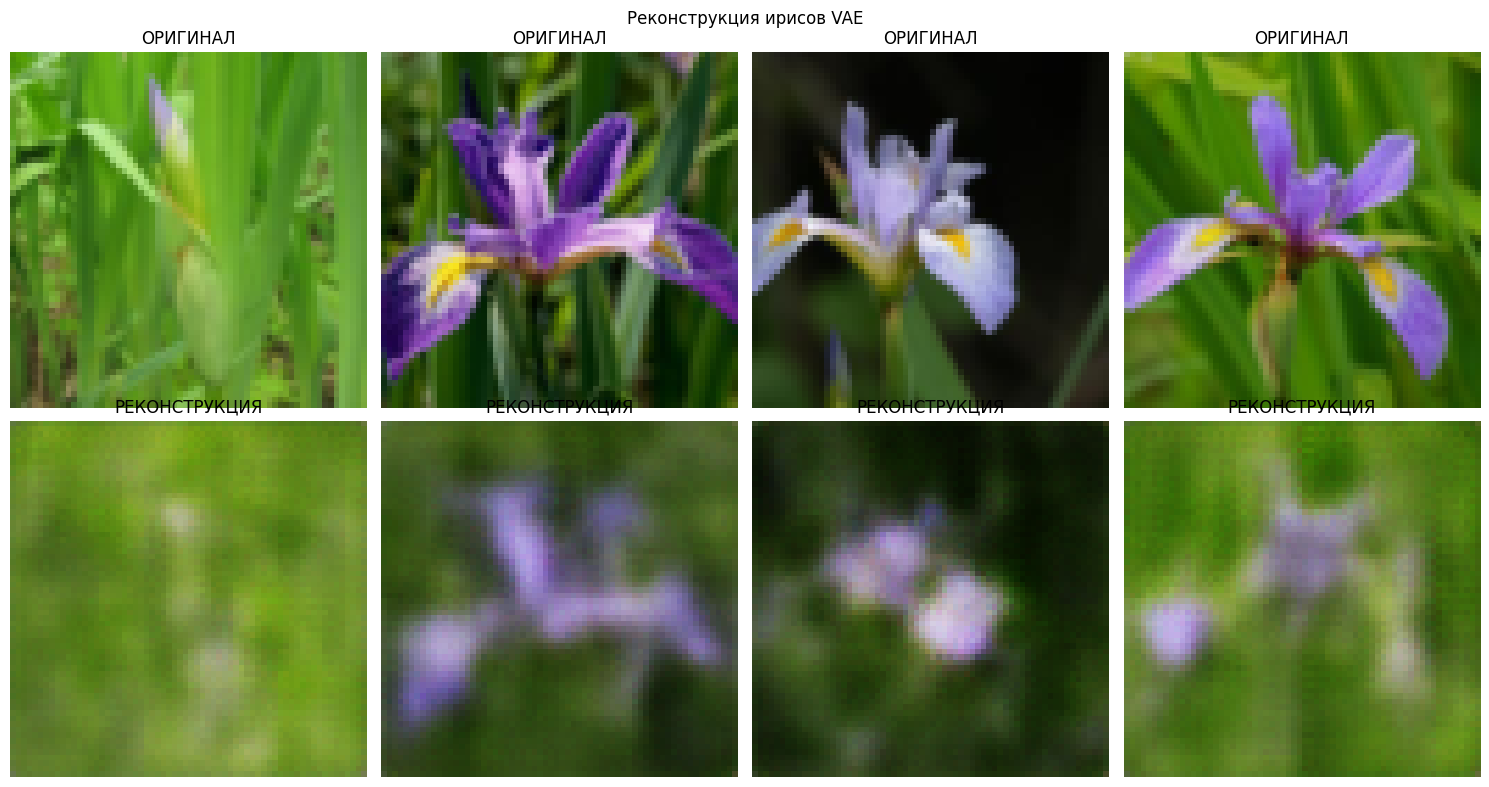

 Сохраненные файлы: best_iris_vae.pth, samples/*.png


In [ ]:
# Загружаем ЛУЧШУЮ модель
vae.load_state_dict(torch.load("best_iris_vae.pth", weights_only=True))
vae.eval()

print("=== РЕАЛЬНЫЕ vs СГЕНЕРИРОВАННЫЕ ИРИСЫ ===")

# 1. Реальные изображения
print("1. РЕАЛЬНЫЕ ирисы:")
show_sample_batch(test_loader, "Реальные ирисы (тест)")

# 2. Сгенерированные изображения
print("2. СГЕНЕРИРОВАННЫЕ ирисы:")
generate_samples(vae, n_samples=16, name="final_best_iris")

# 3. Реконструкция (энкодер+декодер)
print("3. РЕКОНСТРУКЦИЯ (x -> z -> x):")


def show_reconstruction(model, loader, n_samples=8):
    model.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        batch = batch[:n_samples].to(device)
        recon = model.decoder.sample(model.encoder.sample(batch))

        fig, axes = plt.subplots(2, 4, figsize=(15, 8))
        for i, ax in enumerate(axes[0]):
            ax.imshow(batch[i].permute(1, 2, 0).cpu().clamp(0, 1))
            ax.set_title("ОРИГИНАЛ")
            ax.axis("off")
        for i, ax in enumerate(axes[1]):
            ax.imshow(recon[i].permute(1, 2, 0).cpu().clamp(0, 1))
            ax.set_title("РЕКОНСТРУКЦИЯ")
            ax.axis("off")
        plt.suptitle("Реконструкция ирисов VAE")
        plt.tight_layout()
        plt.show()


show_reconstruction(vae, test_loader)

print(" Сохраненные файлы: best_iris_vae.pth, samples/*.png")


***

## **Выводы**

В рамках данного домашнего задания была построена и обучена **вариационная автоэнкодерная модель (VAE)** для генерации изображений **цветков ириса** из датасета *Iris Computer Vision* (Kaggle).

### **Основные шаги:**
1. Был загружен и подготовлен датасет — 421 изображение трёх видов ирисов.  
2. Изображения были уменьшены до **64×64×3** для ускорения обучения.  
3. Реализованы:
   - Свёрточный **Encoder**, кодирующий изображение в латентное пространство размерности 128.  
   - **Decoder** на транспонированных свёртках, восстанавливающий изображение из латентного вектора.  
   - Полная модель **VAE** с нормальным априорным распределением.  
4. Использован **логарифмический бернулли-ликлад (log-bernoulli)** как функция реконструкции, а также KL-дивергенция для регуляризации.  
5. Обучение проходило на GPU с **ранней остановкой**, всего 62 эпохи (из 150 возможных).  

### **Результаты:**
- Итоговая метрика **NLL (Negative Log-Likelihood)** на тестовой выборке: ~**183 531**.  
- Наблюдалось стабильное улучшение функции потерь в течение первых 40 эпох.  
- После обучения модель успешно **генерирует размытые изображения ирисов**, просматривается расположение и форма цветовых переходов.  
- Визуальная проверка показала, что реконструкция сохраняет общие цветовые тона и форму цветка, хотя некоторые детали искажаются.  

### **Вывод:**
Модель продемонстрировала способность изучать распределение изображений цветков и **генерировать новые, варианты**, а также восстанавливать исходные изображения из латентного пространства. Это подтверждает корректность архитектуры и эффективность подхода к обучению на относительно небольшом датасете (421 изображение). С увеличение кол-ва изображений и пикселей ожидается улучшение качества

***